In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
def generate_engine_data(
    n_engines=50,
    min_cycles=100,
    max_cycles=300,
    n_sensors=6
):

    data = []

    for engine_id in range(1, n_engines + 1):

        life = np.random.randint(min_cycles, max_cycles)

        for t in range(life):

            health = 1 - (t / life)

            sensors = []

            for s in range(n_sensors):

                base = np.random.uniform(0.5, 1.5)

                noise = np.random.normal(0, 0.05)

                degrade = base * (1 - 0.6 * (1 - health)) + noise

                sensors.append(degrade)

            # RUL = Remaining Useful Life
            data.append(
                [engine_id, t] + sensors + [life - t]
            )

    cols = (
        ["engine_id", "cycle"]
        + [f"s{i+1}" for i in range(n_sensors)]
        + ["RUL"]
    )

    return pd.DataFrame(data, columns=cols)

df = generate_engine_data()

print(df.head())


   engine_id  cycle        s1        s2        s3        s4        s5  \
0          1      0  0.965271  0.561378  1.247492  1.199435  0.702606   
1          1      1  0.839706  1.305957  0.551921  1.091082  0.952696   
2          1      2  0.678842  0.996750  1.531142  1.277330  0.456115   
3          1      3  0.803725  1.196550  0.578256  1.003966  0.554705   
4          1      4  0.856742  1.403665  1.249726  1.007700  1.131625   

         s6  RUL  
0  1.427228  256  
1  1.431725  255  
2  0.719689  254  
3  0.782663  253  
4  1.398220  252  


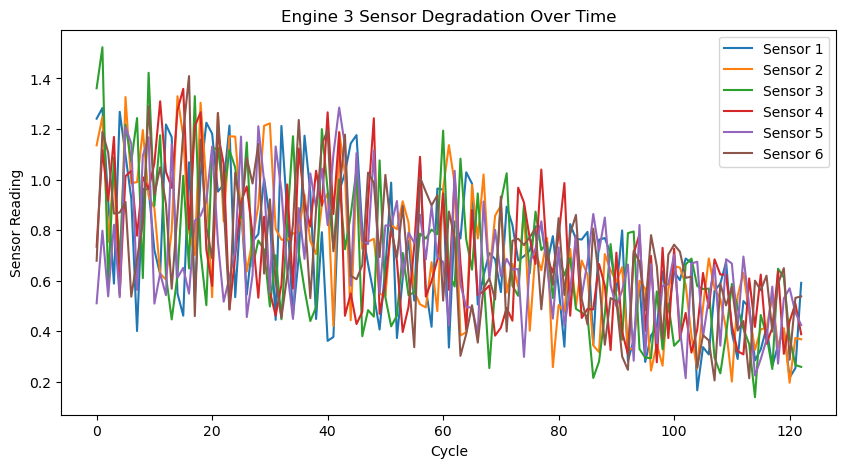

In [3]:
engine_example = df[df.engine_id == 3]

plt.figure(figsize=(10,5))

for i in range(1, 7):

    plt.plot(
        engine_example["cycle"],
        engine_example[f"s{i}"],
        label=f"Sensor {i}"
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor Reading")
plt.title("Engine 3 Sensor Degradation Over Time")
plt.legend()
plt.show()


In [4]:
sensor_cols = [c for c in df.columns if c.startswith("s")]

scaler = StandardScaler()

df[sensor_cols] = scaler.fit_transform(df[sensor_cols])

print("\nNormalized Sensor Data:")
print(df.head())


Normalized Sensor Data:
   engine_id  cycle        s1        s2        s3        s4        s5  \
0          1      0  0.963231 -0.485721  1.963941  1.814831  0.004829   
1          1      1  0.506911  2.210898 -0.538914  1.421336  0.911709   
2          1      2 -0.077691  1.091054  2.984595  2.097716 -0.889003   
3          1      3  0.376150  1.814665 -0.444154  1.104964 -0.531491   
4          1      4  0.568822  2.564764  1.971980  1.118524  1.560544   

         s6  RUL  
0  2.639631  256  
1  2.656009  255  
2  0.062888  254  
3  0.292230  253  
4  2.533989  252  


In [5]:
SEQ_LEN = 50

def make_sequences(df, seq_len=SEQ_LEN):

    X = []
    y = []

    for eid in df.engine_id.unique():

        subset = df[df.engine_id == eid].sort_values("cycle")

        features = subset[sensor_cols].values

        labels = subset["RUL"].values

        for i in range(len(subset) - seq_len):

            X.append(features[i:i+seq_len])

            y.append(labels[i+seq_len])

    return np.array(X), np.array(y)

X, y = make_sequences(df)

print("\nSequence Shapes:")
print("X shape:", X.shape)
print("y shape:", y.shape)


Sequence Shapes:
X shape: (7012, 50, 6)
y shape: (7012,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain Samples:", X_train.shape[0])
print("Test Samples:", X_test.shape[0])


Train Samples: 5609
Test Samples: 1403


In [7]:
n_features = X_train.shape[2]

model = keras.Sequential([

    layers.Input(shape=(SEQ_LEN, n_features)),

    layers.LSTM(
        128,
        return_sequences=True
    ),

    layers.Dropout(0.3),

    layers.LSTM(64),

    layers.Dropout(0.3),

    layers.Dense(
        32,
        activation='relu'
    ),

    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50, 128)             │          69,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 120,641 (471.25 KB)

 Trainable params: 120,641 (471.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_rul_model.keras",
    save_best_only=True
)

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=128,

    callbacks=[early_stop, checkpoint],

    verbose=1
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step - loss: 9197.2295 - mae: 78.3607 - val_loss: 7796.7397 - val_mae: 70.0766
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - loss: 7063.9375 - mae: 65.1497 - val_loss: 5821.6362 - val_mae: 57.6089
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - loss: 5190.3276 - mae: 54.6155 - val_loss: 4246.3643 - val_mae: 49.8386
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 269ms/step - loss: 3909.9487 - mae: 48.8406 - val_loss: 3467.4688 - val_mae: 46.9809
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - loss: 3386.7886 - mae: 47.4587 - val_loss: 3281.7307 - val_mae: 47.2476
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - loss: 3293.7976 - mae: 47.7994 - val_loss: 3271.4829 - val_mae: 47.6428
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - loss: 3293.6726 - mae: 48.1783 - val_loss: 3273.7573 - val_mae: 47.7637
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 188ms/step - loss: 3325.4290 - mae: 48.2342 - val_loss: 3271.5198 - val_mae

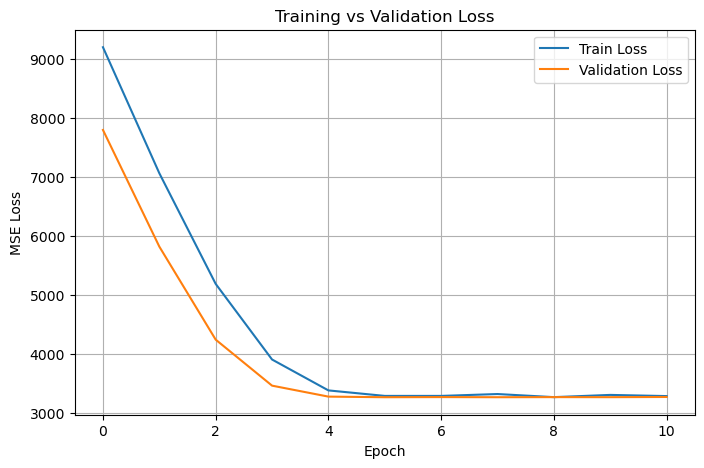

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

Test MAE: 46.91
Test RMSE: 55.70


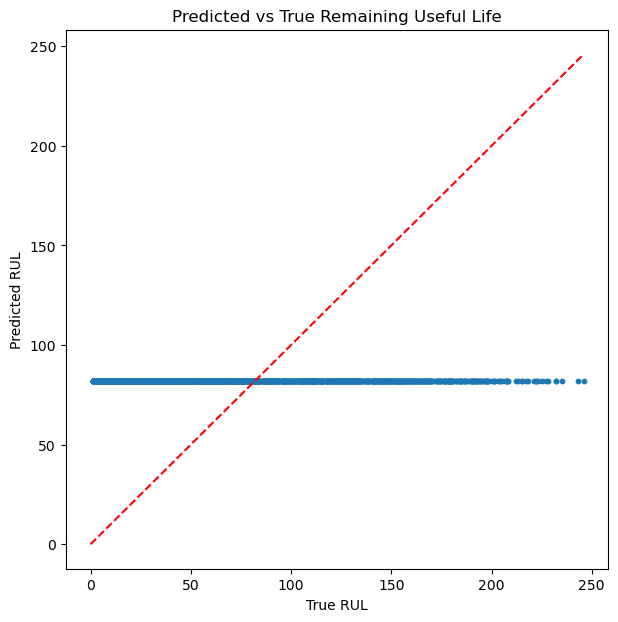

In [10]:
pred = model.predict(X_test).flatten()

mae = np.mean(np.abs(pred - y_test))

rmse = np.sqrt(np.mean((pred - y_test)**2))

print(f"\nTest MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

# =========================
# 11. PREDICTED VS TRUE RUL
# =========================

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    pred,
    s=10
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")

plt.plot(
    [0, max(y_test)],
    [0, max(y_test)],
    'r--'
)

plt.title("Predicted vs True Remaining Useful Life")

plt.show()

In [11]:
model.save("rul_predictor.keras")

print("\nModel Saved Successfully")

# =========================
# 13. LOAD MODEL
# =========================

reloaded = keras.models.load_model(
    "rul_predictor.keras"
)

print("\nReloaded Model Successfully")


Model Saved Successfully

Reloaded Model Successfully


In [12]:
def make_sequence_for_engine(engine_id):

    engine_data = (
        df[df.engine_id == engine_id]
        .sort_values("cycle")
    )

    if len(engine_data) < SEQ_LEN:

        pad = pd.DataFrame(
            0,
            index=range(SEQ_LEN - len(engine_data)),
            columns=sensor_cols
        )

        seq = pd.concat(
            [pad, engine_data[sensor_cols]],
            axis=0
        )

    else:

        seq = engine_data[sensor_cols].iloc[-SEQ_LEN:]

    return np.expand_dims(seq.values, axis=0)

engine_id = int(input("Enter engine number (1-50): "))

seq = make_sequence_for_engine(engine_id)

predicted_rul = model.predict(seq)[0][0]

actual_rul = (
    df[df.engine_id == engine_id]["RUL"]
    .iloc[-1]
)

print(f"\nEngine {engine_id}")
print(f"Predicted RUL: {predicted_rul:.2f}")
print(f"Actual RUL: {actual_rul}")

Enter engine number (1-50):  21


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

Engine 21
Predicted RUL: 81.91
Actual RUL: 1



Enter engine number for visualization:  21


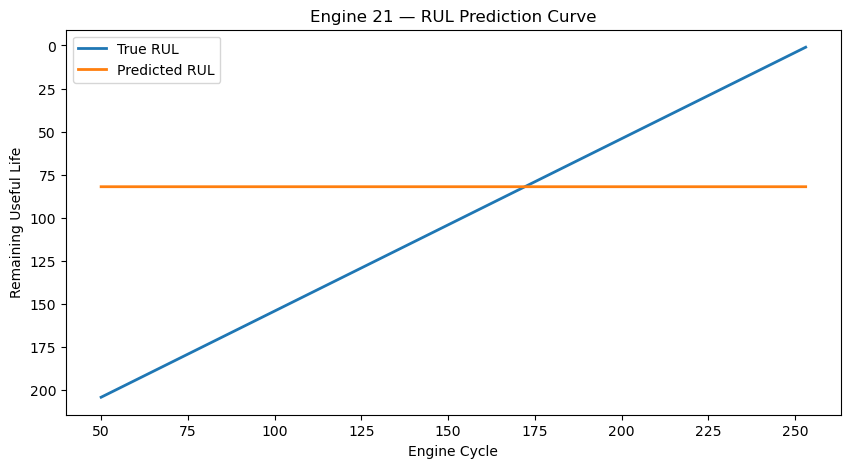

In [14]:
engine_id = int(input("\nEnter engine number for visualization: "))

engine_data = (
    df[df.engine_id == engine_id]
    .sort_values("cycle")
)

preds = []

for i in range(SEQ_LEN, len(engine_data)):

    seq = engine_data[sensor_cols].iloc[i-SEQ_LEN:i]

    seq_scaled = np.expand_dims(
        seq.values,
        axis=0
    )

    pred = model.predict(
        seq_scaled,
        verbose=0
    )[0][0]

    preds.append(pred)

plt.figure(figsize=(10,5))

plt.plot(
    engine_data["cycle"].iloc[SEQ_LEN:],
    engine_data["RUL"].iloc[SEQ_LEN:],
    label="True RUL",
    lw=2
)

plt.plot(
    engine_data["cycle"].iloc[SEQ_LEN:],
    preds,
    label="Predicted RUL",
    lw=2
)

plt.gca().invert_yaxis()

plt.xlabel("Engine Cycle")
plt.ylabel("Remaining Useful Life")

plt.title(
    f"Engine {engine_id} — RUL Prediction Curve"
)

plt.legend()
plt.show()


In [17]:
import gradio as gr
import plotly.graph_objects as go

def predict_rul_web(engine_id):

    try:

        engine_id = int(engine_id)

        if engine_id < 1 or engine_id > 50:

            return "Invalid Engine ID", None

        seq = make_sequence_for_engine(engine_id)

        pred = float(
            model.predict(seq, verbose=0)[0][0]
        )

        actual = float(
            df[df.engine_id == engine_id]["RUL"].mean()
        )

        mean_rul = float(df["RUL"].mean())

        if pred > 0.7 * mean_rul:

            status = "Healthy"
            color = "green"

        elif pred > 0.3 * mean_rul:

            status = "Moderate Wear"
            color = "gold"

        else:

            status = "Critical"
            color = "red"

        fig = go.Figure(go.Indicator(

            mode="gauge+number",

            value=pred,

            title={
                'text': f"Engine {engine_id} RUL"
            },

            gauge={

                'axis': {
                    'range': [0, mean_rul * 1.5]
                },

                'bar': {
                    'color': color
                }
            }
        ))

        output_text = f"""
        ## Rolls-Royce Engine {engine_id}

        Predicted RUL: {pred:.2f}

        Average Actual RUL: {actual:.2f}

        Condition: {status}
        """

        return output_text, fig

    except Exception as e:

        return str(e), None

with gr.Blocks() as demo:

    gr.Markdown(
        "# Rolls-Royce Turbofan RUL Predictor"
    )

    with gr.Row():

        with gr.Column():

            engine_input = gr.Number(
                label="Enter Engine ID",
                value=1
            )

            predict_btn = gr.Button(
                "Predict"
            )

        with gr.Column():

            result_text = gr.Markdown()

            gauge_output = gr.Plot()

    predict_btn.click(

        fn=predict_rul_web,

        inputs=engine_input,

        outputs=[
            result_text,
            gauge_output
        ]
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
